In [ ]:
!pip install logicqubit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.3/364.3 kB 7.3 MB/s eta 0:00:00



Total symbolic/numerical ratio
---------------------------------------------------------------------------
qubits          time ratio        memory ratio
---------------------------------------------------------------------------
     2              12.26x               8.11x
     3              50.99x              12.11x
     4              76.16x              17.17x
     5             286.00x              36.07x
---------------------------------------------------------------------------


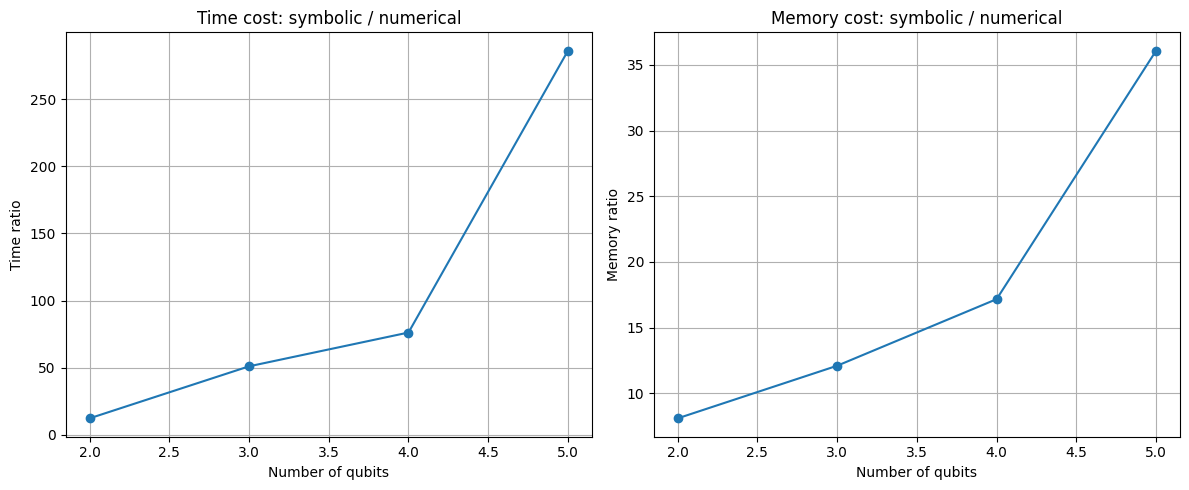

In [ ]:
import gc
import time
import tracemalloc

from logicqubit.logic import *

N_QUBITS = [2, 3, 4, 5]
REPEATS = 3
DO_MEASUREMENT = True

def measure_time_and_memory(function):
    gc.collect()
    tracemalloc.start()

    start = time.perf_counter()
    result = function()
    elapsed_time = time.perf_counter() - start

    current_memory, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    peak_memory_mb = peak_memory / 1024**2

    return result, elapsed_time, peak_memory_mb

def build_circuit(n_qubits, symbolic):
    lq = LogicQuBit(n_qubits, symbolic=symbolic)
    qubits = [Qubit() for _ in range(n_qubits)]

    for q in qubits:
        q.H()

    for i in range(n_qubits - 1):
        qubits[i + 1].CNOT(qubits[i])

    return lq, qubits

def measure_qubits(lq, qubits, symbolic):
    if symbolic:
        lq.setSymbolValuesForAll(1, 0)

    probabilities = lq.Measure(qubits)
    return probabilities

def average(values):
    return sum(values) / len(values)

results = []

for n_qubits in N_QUBITS:
    for symbolic in [False, True]:

        mode = "symbolic" if symbolic else "numerical"

        circuit_times = []
        circuit_memories = []

        measurement_times = []
        measurement_memories = []

        total_times = []
        total_memories = []

        for _ in range(REPEATS):

            # Circuit evolution
            (lq, qubits), circuit_time, circuit_memory = measure_time_and_memory(
                lambda: build_circuit(n_qubits, symbolic)
            )

            circuit_times.append(circuit_time)
            circuit_memories.append(circuit_memory)

            # Measurement and probability distribution
            if DO_MEASUREMENT:
                probabilities, measurement_time, measurement_memory = measure_time_and_memory(
                    lambda: measure_qubits(lq, qubits, symbolic)
                )

                measurement_times.append(measurement_time)
                measurement_memories.append(measurement_memory)

                total_times.append(circuit_time + measurement_time)

                # Since memory was measured separately for each step,
                # the total peak memory is estimated as the largest peak
                total_memories.append(max(circuit_memory, measurement_memory))

        results.append({
            "qubits": n_qubits,
            "mode": mode,
            "step": "circuit evolution",
            "average_time": average(circuit_times),
            "average_memory": average(circuit_memories),
        })

        if DO_MEASUREMENT:
            results.append({
                "qubits": n_qubits,
                "mode": mode,
                "step": "measurement distribution",
                "average_time": average(measurement_times),
                "average_memory": average(measurement_memories),
            })

            results.append({
                "qubits": n_qubits,
                "mode": mode,
                "step": "total",
                "average_time": average(total_times),
                "average_memory": average(total_memories),
            })

print()
print("Total symbolic/numerical ratio")
print("-" * 75)
print(
    f"{'qubits':>6}  "
    f"{'time ratio':>18}  "
    f"{'memory ratio':>18}"
)
print("-" * 75)

ratio_qubits = []
time_ratios = []
memory_ratios = []

for n_qubits in N_QUBITS:

    numerical_total = None
    symbolic_total = None

    for row in results:
        if row["qubits"] == n_qubits and row["step"] == "total":
            if row["mode"] == "numerical":
                numerical_total = row
            elif row["mode"] == "symbolic":
                symbolic_total = row

    if numerical_total is not None and symbolic_total is not None:
        time_ratio = symbolic_total["average_time"] / numerical_total["average_time"]
        memory_ratio = symbolic_total["average_memory"] / numerical_total["average_memory"]

        ratio_qubits.append(n_qubits)
        time_ratios.append(time_ratio)
        memory_ratios.append(memory_ratio)

        print(
            f"{n_qubits:>6}  "
            f"{time_ratio:>17.2f}x  "
            f"{memory_ratio:>17.2f}x"
        )

print("-" * 75)

# Plot symbolic/numerical costs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(ratio_qubits, time_ratios, marker="o")
axes[0].set_title("Time cost: symbolic / numerical")
axes[0].set_xlabel("Number of qubits")
axes[0].set_ylabel("Time ratio")
axes[0].grid(True)

axes[1].plot(ratio_qubits, memory_ratios, marker="o")
axes[1].set_title("Memory cost: symbolic / numerical")
axes[1].set_xlabel("Number of qubits")
axes[1].set_ylabel("Memory ratio")
axes[1].grid(True)

plt.tight_layout()
plt.show()